In [1]:
import math
import numpy as np
from scipy.signal import firwin, filtfilt
import torch
import matplotlib.pyplot as plt
from myPytorchModels import TimeSeriesConv as myNetMdl
from csv2numpy import prepTimeSeqData


In [2]:

# set params -------------------------------------------------------------------------------------
hzn = 1 # EVALUATION sample time, s
groupsize=15
numgroups=5
numgroupsunpaired=2
#fc = np.array([4,10,27,60,90]) # freq band center freqs
fc = np.array([4,10,27]) # freq band center freqs
netfile = ""
dt_target = 0.01 # model sample time, s
seq_len = 128 # model transformer samples
hzn_len = math.ceil(hzn / dt_target)  # horizon as multiple of MODEL Ts, NOT data Ts 
filtorder = 201


In [ ]:

# train simpler model(s) for comparison ------------------------------------------------------

# autoregressive model for each feature
print("Training autoregressive model for each feature...")
_, _, _, _, _, X, Y, _, _, _, _, _, _ = prepTimeSeqData(
    seq_len=seq_len, hzn_len=1, dt_target=dt_target, drawFromStart=True, maxNumel=5e8)
Mar = []
for f in range(Y.shape[-1]):
    x = X[:,:,f]
    y = Y[:,0,f]
    A = np.linalg.lstsq(x, y, rcond=None)[0]
    Mar.append(A)
Mar = np.stack(Mar, axis=1)
del X, Y, A, x, y


In [ ]:

# linear regression model using all features
print("Training linear regression model using all features...")
_, _, _, _, _, X, Y, _, _, _, _, _, _ = prepTimeSeqData(
    seq_len=1, hzn_len=1, dt_target=dt_target, drawFromStart=True, maxNumel=5e5)
X = X[:,-1,:]
Y = Y[:,0,:]
Mlin = np.linalg.lstsq(X, Y, rcond=None)[0]
print(X.shape, Y.shape, Mlin.shape)
#del X, Y


In [ ]:
Ytrainpred = X @ Mlin
Ytrainerr = Y - Ytrainpred
Ytrainrms = np.sqrt(np.mean(Ytrainerr**2, axis=0)) / (np.sqrt(np.mean(Y**2, axis=0)) + np.finfo(float).eps)
# make a bar plot of the normalized RMS error for each feature
plt.figure(figsize=(10,6))
plt.bar(np.arange(Y.shape[1]), Ytrainrms)
plt.xlabel("Feature index")
plt.ylabel("Normalized RMS error")
plt.title("Linear regression model training error")
plt.grid()
plt.show()

In [3]:

# Prepare the Data ---------------------------------------------------------------------

#device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
device = torch.device('cpu')

fs, feature_names, feature_correction, Xs, Ys, Xb, Yb, _, YsRaw, _, YbRaw, Us, Ub = prepTimeSeqData(
    seq_len=seq_len, hzn_len=hzn_len, dt_target=dt_target, drawFromStart=False, maxNumel=1e9)
Xs = torch.tensor(Xs, dtype=torch.float32)
Ys = torch.tensor(Ys, dtype=torch.float32)
Xb = torch.tensor(Xb, dtype=torch.float32)
Yb = torch.tensor(Yb, dtype=torch.float32)
Us = torch.tensor(Us, dtype=torch.float32)
Ub = torch.tensor(Ub, dtype=torch.float32)

filtwts = firwin(filtorder, [2, 40], pass_zero=False, fs=1/dt_target)
print(YsRaw.shape)
print(YbRaw.shape)
YsRaw = filtfilt(filtwts, 1, YsRaw, axis=0)
YbRaw = filtfilt(filtwts, 1, YbRaw, axis=0)
print(YsRaw.shape)
print(YbRaw.shape)
#YsRaw = torch.tensor(YsRaw, dtype=torch.float32)
#YbRaw = torch.tensor(YbRaw, dtype=torch.float32)

# -----------------------------------------------------------------------------------------------


Sampling frequency (Hz): 1000.0
Baseline outliers: 54 of 26581
Data outliers: 0 of 26581
Baseline Pairs created: 14059
Input shape : (14059, 128, 165)
Output shape: (14059, 100, 165)
Event shape: (14059, 100, 1)
Main Pairs created: 24301
Input shape : (24301, 128, 165)
Output shape: (24301, 100, 165)
Event shape: (24301, 100, 1)
(24301, 100, 15)
(14059, 100, 15)
(24301, 100, 15)
(14059, 100, 15)


In [11]:

# define mdl struct ====================================================================
model = myNetMdl(dim_in=Xb.shape[-1], dim_out=Yb.shape[-1], time_len=seq_len, group_size=groupsize, num_groups=numgroups, tuple_size=3, numGrpUnpaired=numgroupsunpaired)
if netfile:
    model.load_state_dict(torch.load(netfile, map_location=device))
else:
    # bias the model frequency prediction to the center of each band 
    fcenter = torch.tensor(fc, dtype=torch.float32)
    fbias = fcenter.repeat_interleave(groupsize)
    fbias = fbias*dt_target*2*math.pi # scale by model sample time and 2pi to convert to radians
    with torch.no_grad():
        model.fcoFreq.bias.copy_(fbias)


In [5]:

# simulations -----------------------------------------------------------------------------------

# recover filtered signal from processed features 
def unprocess(Y, featcorrection):
    numGrpIgnored = numgroupsunpaired # last two groups will not be used
    N = (numgroups-numGrpIgnored)*groupsize
    Ymag = Y[..., :N]
    Ycos = Y[..., N:2*N]
    Ysin = Y[..., 2*N:3*N]
    print(Ymag.shape, Ycos.shape, Ysin.shape)
    Ymag = np.sqrt(np.exp(Ymag)) * featcorrection[:(numgroups-numGrpIgnored)*groupsize]
    #Ytan = Ysin / (Ycos + np.finfo(float).eps)
    Yphase = np.arctan2(Ysin, Ycos)
    Yreal = Ymag * np.cos(Yphase)
    #Yreal = Ymag * Ycos
    return Yreal


In [6]:

def run_examplesim(U, X, Y, Ytrue_recon=None):

    # run simulations 
    Ysim, Yar, Ylin = [], [], []
    model.eval()
    print("example simulations...")
    for i in range(Y.shape[0]):
        xi = X[i:i+1,:,:]
        ui = U[i:i+1,:,:]
        
        # using rollout: 
        with torch.no_grad():
            yi = model(xi, ui)
        Ysim.append(yi[0,:,:])
        """
        # without using rollout:
        for j in range(hzn_len):
            uj = ui[:,j:j+1,:] 
            with torch.no_grad():
                yj = model(xi, uj)
            # prepare next input
            xi = torch.cat([xi[0:1, 1:, :], yj], dim=1) 
            Ysim.append(yj[0,:,:])
        """
        """
        yyar = []
        #yylin = []
        Xnp = X[i,:,:].numpy()
        x = Xnp[-1,:]
        for j in range(hzn_len):
            #ylin = x @ Mlin
            #yylin.append(ylin)
            #x = ylin
            yar = []
            for f in range(Y.shape[-1]):
                xf = Xnp[:,f]
                yarf = xf @ Mar[:,f]
                yar.append(yarf)
            yyar.append(yar)
            Xnp = np.vstack([Xnp[1:,:], np.array(yar)])
        Yar.append(yyar)
        #Ylin.append(yylin)

    Yar = np.array(Yar)
    #Ylin = np.array(Ylin)
    print("Yar shape:", Yar.shape)
    #print("Ylin shape:", Ylin.shape)
    """

    Ysim = np.array(Ysim)
    Ytrue = Y.numpy()
    print("Ysim shape :", Ysim.shape)
    print("Ytrue shape:", Ytrue.shape)

    # choose features to display
    maxNdisp = 8
    example_indices = np.arange(0, X.shape[-1], groupsize)
    example_indices = np.concatenate((
        example_indices[:(numgroups-numgroups)], 
        example_indices[-numgroupsunpaired:], 
        example_indices[2*(numgroups-numgroups):-numgroupsunpaired]), 
        axis=0)
    example_indices = example_indices[:maxNdisp]

     # feature plots 
    fig, axes = plt.subplots(len(example_indices)+1, 1, sharex=True, figsize=(10, 8))
    for ax, idx in zip(axes, example_indices):
        ax.plot(Ytrue[:,:, idx].flatten(), label="True")
        ax.plot(Ysim[:,:, idx].flatten(), label="Simulated", alpha=0.7)
        #ax.plot(Yar[:,:, idx].flatten(), label="AR Sim", alpha=0.6)
        #ax.plot(Ylin[:,:, idx].flatten(), label="Linear Sim", alpha=0.5)
        ymin = Ytrue[:,:, idx].min()
        ymax = Ytrue[:,:, idx].max()
        yrange = ymax - ymin
        ymin -= yrange * 0.1
        ymax += yrange * 0.1
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel("Feature Value")
        ax.set_title(f"Feature: {feature_names[idx]}")
        ax.legend(fontsize='xx-small')
        ax.grid(axis='both')
    # plot stim input
    axes[-1].plot(U[:,:,-1].flatten())
    axes[-1].set_title("Stimulus Input")
    axes[-1].set_ylabel("Count")
    axes[-1].grid(axis='both')
    axes[-1].set_xlabel("Sample")  # Set x-label only on the last subplot
    plt.tight_layout()
    plt.show()

    # channel data reconstruction
    Ysim_grouped = unprocess(Ysim, feature_correction)
    Ytrue_grouped = unprocess(Ytrue, feature_correction)
    #Yar_grouped = unprocess(Yar, feature_correction)
    #Ylin_grouped = unprocess(Ylin, feature_correction)
    N = numgroups-numgroupsunpaired
    Ysim_grouped = Ysim_grouped[..., :N*groupsize]
    Ytrue_grouped = Ytrue_grouped[..., :N*groupsize]
    #Yar_grouped = Yar_grouped[..., :N*groupsize]
    #Ylin_grouped = Ylin_grouped[..., :N*groupsize]
    Ysim_grouped = Ysim_grouped.reshape(Ysim.shape[0], -1, N, groupsize)
    Ytrue_grouped = Ytrue_grouped.reshape(Ytrue.shape[0], -1, N, groupsize)
    #Yar_grouped = Yar_grouped.reshape(Yar.shape[0], -1, N, groupsize)
    #Ylin_grouped = Ylin_grouped.reshape(Ylin.shape[0], -1, N, groupsize)
    Ysim_recon = np.sum(Ysim_grouped, axis=-2)
    #Yar_recon = np.sum(Yar_grouped, axis=-2)
    #Ylin_recon = np.sum(Ylin_grouped, axis=-2)
    if Ytrue_recon is None:
        Ytrue_recon = np.sum(Ytrue_grouped, axis=-2)
    example_indices = np.arange(maxNdisp)
    print("Ysim shape :", Ysim_recon.shape)
    #print("Yar shape:", Yar_recon.shape)
    #print("Ylin shape:", Ylin_recon.shape)
    print("Ytrue shape:", Ytrue_recon.shape)

    # channel plots
    fig, axes = plt.subplots(len(example_indices)+1, 1, sharex=True, figsize=(10, 8))
    for ax, idx in zip(axes, example_indices):
        ax.plot(Ytrue_recon[:,:, idx].T.flatten(), label="True")
        ax.plot(Ysim_recon[:,:, idx].T.flatten(), label="Simulated", alpha=0.7)
        #ax.plot(Yar_recon[:,:, idx].T.flatten(), label="AR Sim", alpha=0.6)
        #ax.plot(Ylin_recon[:,:, idx].T.flatten(), label="Linear Sim", alpha=0.5)
        ymin = Ytrue_recon[:,:, idx].min()
        ymax = Ytrue_recon[:,:, idx].max()
        yrange = ymax - ymin
        ymin -= yrange * 0.1
        ymax += yrange * 0.1
        ax.set_ylim(ymin, ymax)
        ax.set_ylabel("Channel Value")
        ax.set_title(f"Channel: {idx}")
        ax.legend(fontsize='xx-small')
        ax.grid(axis='both')
    # plot stim input
    axes[-1].plot(U[:,:,-1].flatten())
    axes[-1].set_title("Stimulus Input")
    axes[-1].set_ylabel("Count")
    axes[-1].grid(axis='both')
    axes[-1].set_xlabel("Time Sample")  # Set x-label only on the last subplot
    plt.tight_layout()
    plt.show()


In [7]:

def run_simulation(U, X, Y, Ytrue_recon=None):

    Ysim = []
    model.eval()
    progtick = 0.05
    progcur = 0.0
    prognext = progtick
    print("Simulating...")
    for i0 in range(len(X)):
        xi = X[i0:i0+1,:,:]
        
        # using rollout: 
        ui = U[i0:i0+1,:,:]
        with torch.no_grad():
            yi = model(xi, ui)
        """
        # without using rollout:
        for i in range(hzn_len):
            ui = U[i0:i0+1,i:i+1,:] 
            with torch.no_grad():
                yi = model(xi, ui)
            # prepare next input
            xi = torch.cat([xi[0:1, 1:, :], yi], dim=1)
        """
        
        yi = yi[:,-1,:] # only take final step of rollout for evaluation
        Ysim.append(yi.numpy().flatten())
        progcur += 1.0/(len(X) - hzn_len)
        if progcur >= prognext:
            print(f"  {int(progcur*100)}%")
            prognext += progtick

    # evaluate -------------------------------------------------------------------------------------

    # overall 
    Ysim = np.array(Ysim)
    Ytrue = Y.numpy()
    print("Ysim shape :", Ysim.shape)
    print("Ytrue shape:", Ytrue.shape)
    mse = np.mean((Ysim - Ytrue)**2, axis=0) / (np.mean((Ytrue)**2, axis=0) + np.finfo(float).eps)
    rho = np.array([ np.corrcoef(Ysim[:,i], Ytrue[:,i])[0,1] for i in range(Ytrue.shape[1]) ])
    print("Mean MSE:", np.mean(mse))
    print("Mean correlation:", np.mean(rho))
    # show a bar plot of mse per feature
    barwid = .35
    barx = np.arange(len(mse))
    plt.figure()
    plt.bar(barx-barwid, 1-mse, width=barwid, label="1-MSE")
    plt.bar(barx, rho, width=barwid, label="correlation")
    plt.legend()
    plt.xlabel("Feature index")
    plt.xticks(ticks=range(0, len(mse), groupsize), labels=feature_names[::groupsize], rotation=90, ha='right')
    plt.ylabel("accuracy")
    plt.title("Accuracy per Feature")
    plt.grid(axis='y')
    plt.show()

    # a few example channels 
    # get index of channels sorted by mse
    sorted_indices = np.argsort(rho-mse)  # ascending order
    # get first, middle, and end of sorted_indices
    example_indices = [sorted_indices[0], sorted_indices[len(sorted_indices)//4], sorted_indices[len(sorted_indices)//2], sorted_indices[3*len(sorted_indices)//4], sorted_indices[-1]]
    # Create a single figure with vertically stacked subplots
    fig, axes = plt.subplots(len(example_indices)+1, 1, sharex=True, figsize=(10, 8))
    for ax, idx in zip(axes, example_indices):
        ax.plot(Ytrue[:, idx], label="True")
        ax.plot(Ysim[:, idx], label="Simulated", alpha=0.7)
        ax.set_ylabel("Feature Value")
        ax.set_title(f"Feature: {feature_names[idx]} (MSE: {mse[idx]:.4f}; corr: {rho[idx]:.4f})")
        ax.legend()
        ax.grid(axis='both')
    # plot stim input
    axes[-1].plot(U[:,-1,-1])
    axes[-1].set_title("Stimulus Input")
    axes[-1].set_ylabel("Count")
    axes[-1].grid(axis='both')
    axes[-1].set_xlabel("Sample")  # Set x-label only on the last subplot
    plt.tight_layout()
    plt.show()

    # reconstruct raw signal from filtered bands 
    """
    Ysim_grouped = Ysim[:, :numgroups * groupsize] # * feature_correction[:numgroups * groupsize]
    Ytrue_grouped = Ytrue[:, :numgroups * groupsize] # * feature_correction[:numgroups * groupsize]
    mse_grouped = mse[:numgroups * groupsize].reshape(groupsize, numgroups)
    pinksim = Ysim[:, 2*(numgroups * groupsize):]
    pinktrue = Ytrue[:, 2*(numgroups * groupsize):]
    f = np.tile(fc, (groupsize,1)).T.flatten()
    f = np.column_stack((np.log10(f), np.ones(len(f)))).T
    Ppinksim = np.power(10, pinksim @ f) ** .5
    Ppinktrue = np.power(10, pinktrue @ f) ** .5
    Ysim_grouped = Ysim_grouped * Ppinksim
    Ytrue_grouped = Ytrue_grouped * Ppinktrue
    """
    Ysim_grouped = unprocess(Ysim, feature_correction)
    Ytrue_grouped = unprocess(Ytrue, feature_correction)
    N = numgroups-numgroupsunpaired
    Ysim_grouped = Ysim_grouped[:, :N*groupsize]
    Ytrue_grouped = Ytrue_grouped[:, :N*groupsize]
    Ysim_grouped = Ysim_grouped.reshape(-1, N, groupsize)
    Ytrue_grouped = Ytrue_grouped.reshape(-1, N, groupsize)
    Ysim_recon = np.sum(Ysim_grouped, axis=-2)
    if Ytrue_recon is None:
        Ytrue_recon = np.sum(Ytrue_grouped, axis=-2)
    else:
        Ytrue_recon = Ytrue_recon
    mse_recon = np.mean((Ysim_recon - Ytrue_recon)**2, axis=0) / (np.mean((Ytrue_recon)**2, axis=0) + np.finfo(float).eps)
    rho_recon = np.array([ np.corrcoef(Ysim_recon[:,i], Ytrue_recon[:,i])[0,1] for i in range(Ytrue_recon.shape[1]) ])

    # show a bar plot of mse per feature
    barx = np.arange(len(mse_recon))
    plt.figure()
    plt.bar(barx-barwid, 1-mse_recon, width=barwid, label="1-MSE")
    plt.bar(barx, rho_recon, width=barwid, label="correlation")
    plt.legend()
    plt.xlabel("Channel index")
    plt.ylabel("accuracy")
    plt.title("Accuracy per Channel")
    plt.grid(axis='y')
    plt.show()

    # a few example channels 
    # get index of channels sorted by mse
    sorted_indices = np.argsort(rho_recon-mse_recon)  # ascending order
    # get first, middle, and end of sorted_indices
    example_indices = [sorted_indices[0], sorted_indices[len(sorted_indices)//4], sorted_indices[len(sorted_indices)//2], sorted_indices[3*len(sorted_indices)//4], sorted_indices[-1]]
    # Create a single figure with vertically stacked subplots
    fig, axes = plt.subplots(len(example_indices)+1, 1, sharex=True, figsize=(10, 8))
    for ax, idx in zip(axes, example_indices):
        ax.plot(Ytrue_recon[:, idx], label="True")
        ax.plot(Ysim_recon[:, idx], label="Simulated", alpha=0.7)
        ax.set_ylabel("Channel Value")
        ax.set_title(f"Channel: {idx} (MSE: {mse_recon[idx]:.4f}; corr: {rho_recon[idx]:.4f})")
        ax.legend()
        ax.grid(axis='both')
    # plot stim input
    axes[-1].plot(U[:,-1,-1])
    axes[-1].set_title("Stimulus Input")
    axes[-1].set_ylabel("Count")
    axes[-1].grid(axis='both')
    axes[-1].set_xlabel("Time Sample")  # Set x-label only on the last subplot
    plt.tight_layout()
    plt.show()


Example sim on baseline data...
example simulations...
Ysim shape : (12, 100, 165)
Ytrue shape: (12, 100, 165)


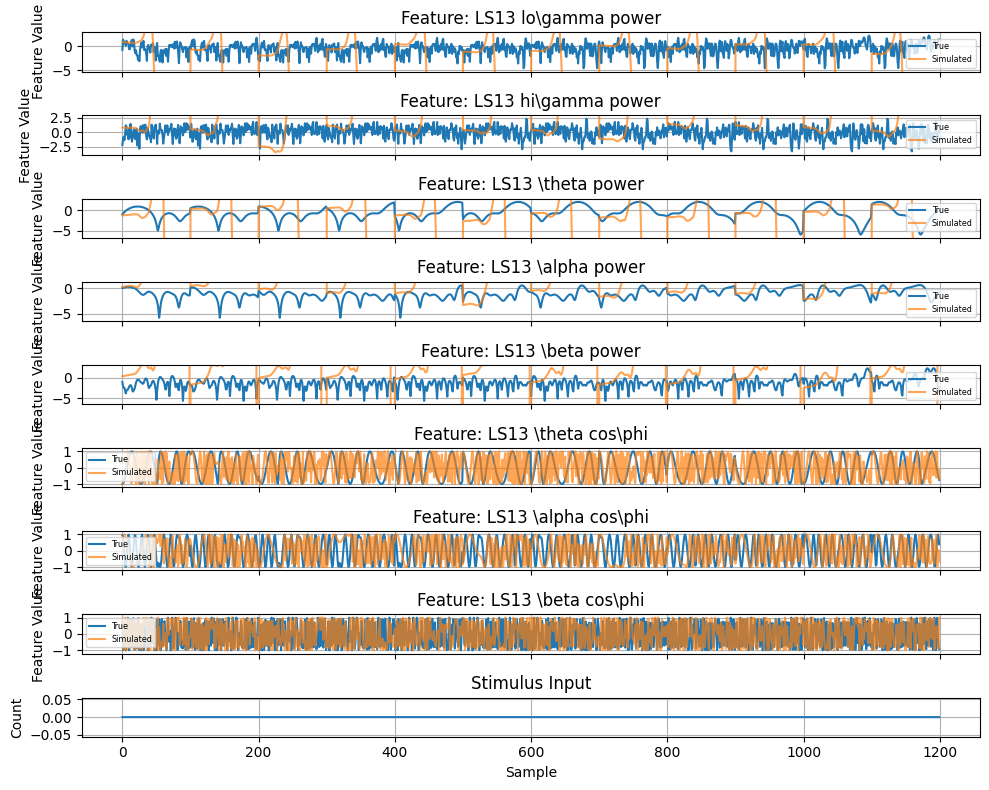

(12, 100, 45) (12, 100, 45) (12, 100, 45)
(12, 100, 45) (12, 100, 45) (12, 100, 45)
Ysim shape : (12, 100, 15)
Ytrue shape: (12, 100, 15)


/var/folders/63/rd6zg9vd5v710s38rhy7y8jc0000gn/T/ipykernel_24574/3998721261.py:11: RuntimeWarning: overflow encountered in exp
  Ymag = np.sqrt(np.exp(Ymag)) * featcorrection[:(numgroups-numGrpIgnored)*groupsize]


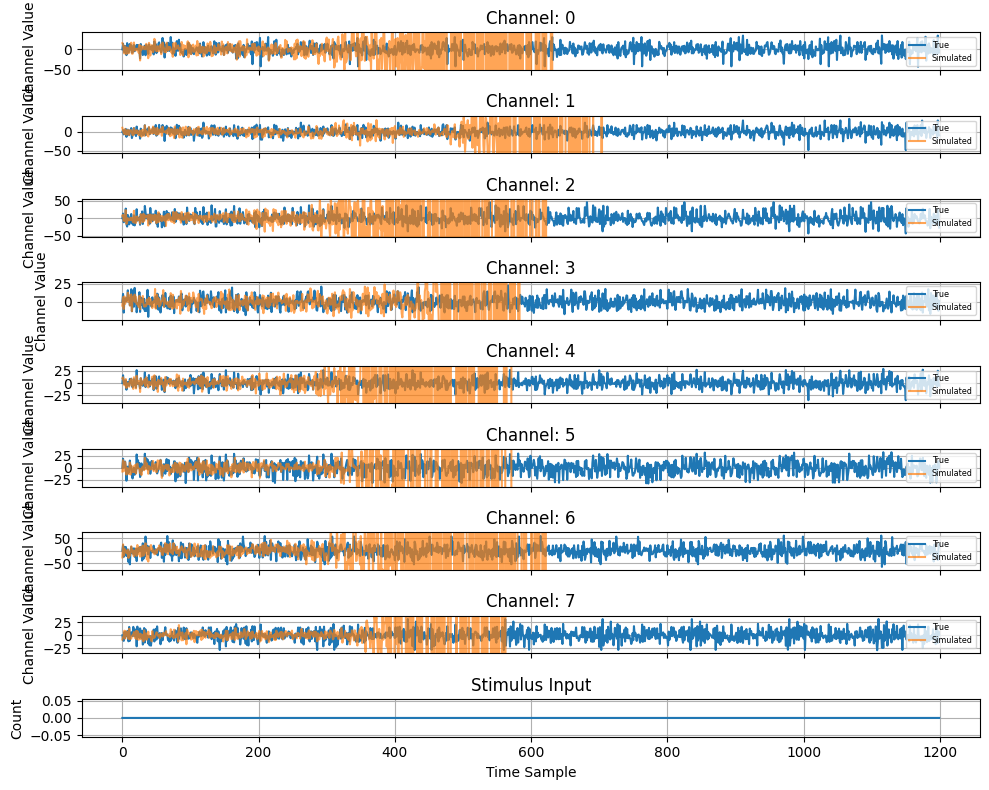

Example sim on stimulated data...
example simulations...
Ysim shape : (12, 100, 165)
Ytrue shape: (12, 100, 165)


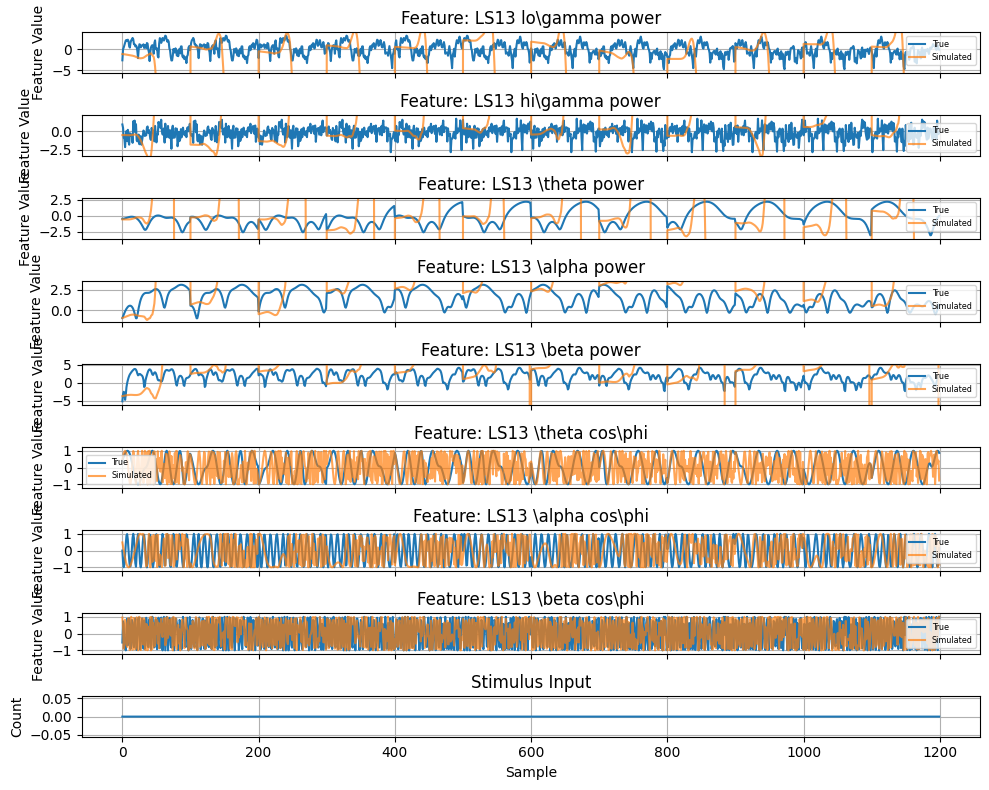

(12, 100, 45) (12, 100, 45) (12, 100, 45)
(12, 100, 45) (12, 100, 45) (12, 100, 45)
Ysim shape : (12, 100, 15)
Ytrue shape: (12, 100, 15)


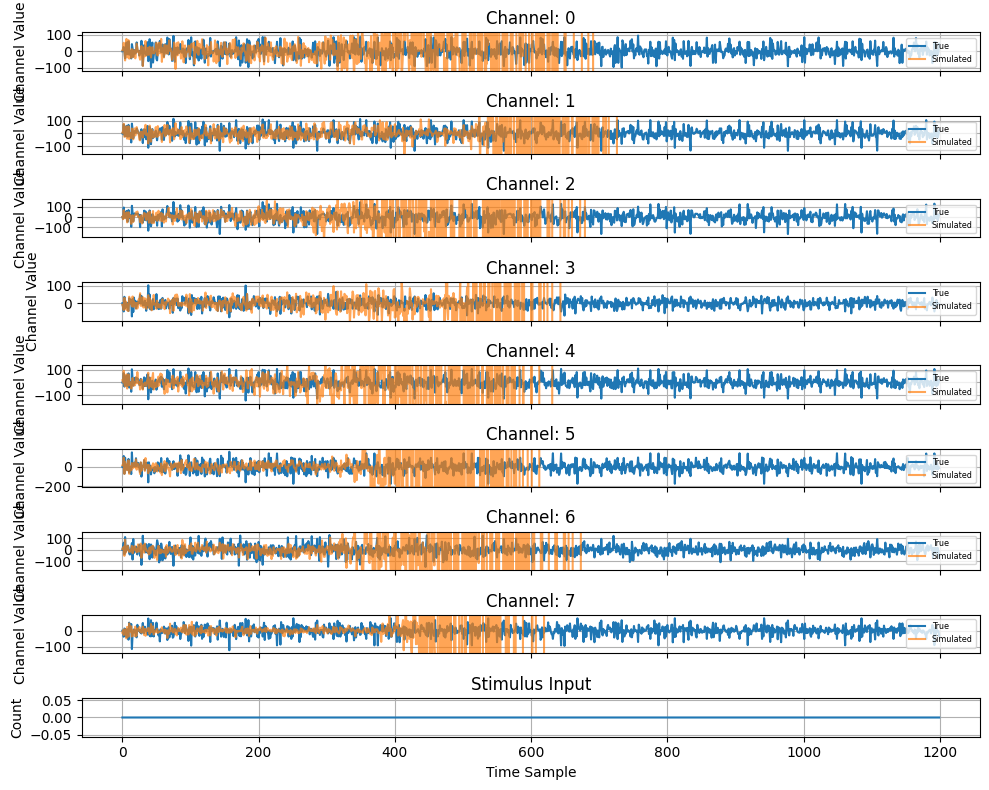

In [12]:

print("Example sim on baseline data...")
examplesel = np.linspace(0,Xb.shape[1]-1,12).astype(int)
run_examplesim(Ub[examplesel], Xb[examplesel], Yb[examplesel], YbRaw[examplesel])

print("Example sim on stimulated data...")
examplesel = np.linspace(0,Xs.shape[1]-1,12).astype(int)
run_examplesim(Us[examplesel], Xs[examplesel], Ys[examplesel], YsRaw[examplesel])


In [ ]:

# for output, only consider the final step of the horizon for evaluation, since that's the hardest to predict and most relevant for control applications.
Ys = Ys[:,-1,:]
Yb = Yb[:,-1,:]
YsRaw = YsRaw[:,-1,:]
YbRaw = YbRaw[:,-1,:]

print("Evaluating baseline data...")
run_simulation(Ub, Xb, Yb, YbRaw)

print("Evaluating stimulated data...")
run_simulation(Us, Xs, Ys, YsRaw)